In [3]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from John_Jellicoe import algoritmo_JJ
from backtracking import resolver_tablero

from auxiliares import generate_test_case, print_tablero

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [ ]:
import time

x = np.linspace(10, 50000, 30).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': []
}
worst_ratio =1
worst_parameters = None
ratios=[]
for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': []
    }

    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(size, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
        optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
        ratios.append(optimality_ratio)
        if optimality_ratio < worst_ratio:
            worst_ratio = optimality_ratio
            worst_parameters = (n, m, ship_lengths, original_row, original_col)
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))

print(f"Peor ratio: {worst_ratio} para {worst_parameters}")


Tamaño 10x16 ...
Tamaño 26x47 ...
Tamaño 43x6 ...
Tamaño 60x53 ...
Tamaño 77x112 ...
Tamaño 94x59 ...
Tamaño 111x160 ...
Tamaño 128x224 ...
Tamaño 145x281 ...
Tamaño 162x273 ...
Tamaño 178x184 ...
Tamaño 195x308 ...
Tamaño 212x347 ...
Tamaño 229x61 ...
Tamaño 246x59 ...
Tamaño 263x165 ...
Tamaño 280x273 ...
Tamaño 297x389 ...
Tamaño 314x505 ...
Tamaño 331x498 ...
Tamaño 347x508 ...
Tamaño 364x659 ...
Tamaño 381x483 ...
Tamaño 398x154 ...
Tamaño 415x593 ...
Tamaño 432x607 ...
Tamaño 449x482 ...
Tamaño 466x366 ...
Tamaño 483x25 ...
Tamaño 500x954 ...
Peor ratio: 0.1700854700854701 para (263, 165, [154, 152, 151, 142, 128, 99, 95, 90, 88, 71], [0, 107, 35, 161, 34, 159, 135, 59, 45, 37, 120, 155, 33, 149, 12, 40, 77, 132, 117, 158, 160, 45, 69, 12, 150, 51, 130, 106, 134, 21, 75, 152, 67, 33, 34, 66, 44, 102, 114, 2, 126, 137, 17, 80, 101, 11, 45, 66, 141, 93, 12, 22, 73, 58, 116, 74, 159, 111, 121, 142, 40, 142, 1, 43, 140, 76, 65, 55, 27, 51, 37, 117, 148, 103, 46, 61, 96, 49, 33, 62, 1

In [ ]:
import time

x = np.linspace(10, 500, 30).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': [],
    "jj_demand_mean":[],
}
worst_ratio =1
worst_parameters = None
ratios=[]
for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': []
    }

    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(size, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
        optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
        ratios.append(optimality_ratio)
        if optimality_ratio < worst_ratio:
            worst_ratio = optimality_ratio
            worst_parameters = (n, m, ship_lengths, original_row, original_col)
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))

print(f"Peor ratio: {worst_ratio} para {worst_parameters}")


In [30]:
ratio_promedio = np.mean(ratios)
print(f"Ratio promedio: {ratio_promedio}")

Ratio promedio: 0.9420710460307776


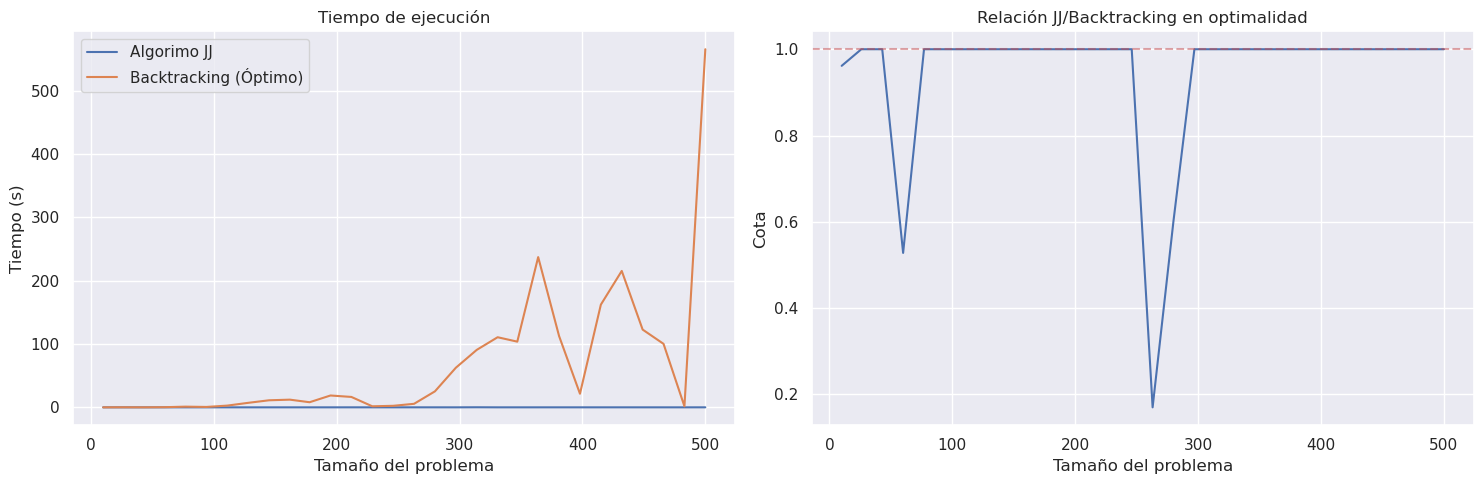

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results['size'], results['jj_time'], label='Algorimo JJ')
ax1.plot(results['size'], results['backtrack_time'], label='Backtracking (Óptimo)')
ax1.set_title('Tiempo de ejecución')
ax1.set_xlabel('Tamaño del problema')
ax1.set_ylabel('Tiempo (s)')
ax1.legend()
# ax1.set_yscale('log')

# Plot optimality ratio
ax2.plot(results['size'], results['optimality_ratio'])
ax2.set_title('Relación JJ/Backtracking en optimalidad')
ax2.set_xlabel('Tamaño del problema')
ax2.set_ylabel('Cota')
ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()


# Calculo para matriz grande (incalculable para algoritmo de BT)

In [ ]:
import time

x = np.linspace(10, 500, 30).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': [],
    "jj_demand_mean":[],
    "bt_demand_mean":[]
}
worst_ratio =1
worst_parameters = None
ratios=[]
for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': [],
        "jj_demand_mean":[],
        "bt_demand_mean":[]

    }

    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(size, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
        optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
        ratios.append(optimality_ratio)
        if optimality_ratio < worst_ratio:
            worst_ratio = optimality_ratio
            worst_parameters = (n, m, ship_lengths, original_row, original_col)
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
        size_results['jj_demand_mean'].append(jj_demand_fulfilled/total_demand)
        size_results['bt_demand_mean'].append(optimal_demand_fulfilled/total_demand)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))
    results['jj_demand_mean'].append(size_results['jj_demand_mean'])
    results['bt_demand_mean'].append(size_results['bt_demand_mean'])
print(f"Peor ratio: {worst_ratio} para {worst_parameters}")


Tamaño 10x20 ...
Tamaño 31x1 ...
Tamaño 52x62 ...
Tamaño 73x39 ...
Tamaño 94x48 ...
Tamaño 115x125 ...
Tamaño 136x204 ...
Tamaño 157x179 ...
Tamaño 178x85 ...
Tamaño 200x66 ...
Peor ratio: 0.7213114754098361 para (10, 20, [9, 9, 8, 8, 7, 7, 6, 3, 2, 2], [8, 12, 12, 10, 10, 20, 19, 11, 15, 10], [10, 5, 10, 8, 9, 5, 9, 6, 10, 8, 5, 8, 6, 6, 9, 6, 9, 5, 2, 10])


In [60]:
demand_mean = np.mean(results['jj_demand_mean'])
print(f"Ratio promedio: {demand_mean}")

bt_demand_mean = np.mean(results['bt_demand_mean'])
print(f"Ratio promedio: {bt_demand_mean}")

Ratio promedio: 0.14322308517013443
Ratio promedio: 0.15855531400690168


In [62]:
import time

x = np.linspace(10, 10000, 3).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': [],
    "jj_demand_mean":[],
}
worst_ratio =1
worst_parameters = None
ratios=[]
for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': [],
        "jj_demand_mean":[],
    }

    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(size, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        #result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        #optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
       # optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
       # ratios.append(optimality_ratio)
       # if optimality_ratio < worst_ratio:
        ##    worst_ratio = optimality_ratio
          #  worst_parameters = (n, m, ship_lengths, original_row, original_col)
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
        size_results['jj_demand_mean'].append(jj_demand_fulfilled/total_demand)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))
    results['jj_demand_mean'].append(np.mean(size_results['jj_demand_mean']))

print(f"Peor ratio: {worst_ratio} para {worst_parameters}")


Tamaño 10x9 ...
Tamaño 5005x8629 ...
Tamaño 10000x290 ...
Peor ratio: 1 para None


In [63]:
demand_mean = np.mean(results['jj_demand_mean'])
print(f"Ratio promedio: {demand_mean}")

Ratio promedio: 0.18800269466903
